# Tesla Stock Price Time Series Analysis

## Introduction
This project analyses Tesla stock prices from 1 January 2015 to 1 January 2026 using time series analysis techniques. The aim is to explore historical behaviour in Tesla's closing stock price, test for stationarity, apply forecasting models and evaluate their performance.

The main variable of interest is the closing price as it reflects the final value of Tesla stock at the end of each trading day.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [8]:
import yfinance as yf

data = yf.download("TSLA", start="2015-01-01", end="2026-01-01")

data.to_csv(r"C:\Users\killi\OneDrive - Dundalk Institute of Technology\tesla-time-series-analysis\data\tesla_stock_data.csv")


[*********************100%***********************]  1 of 1 completed


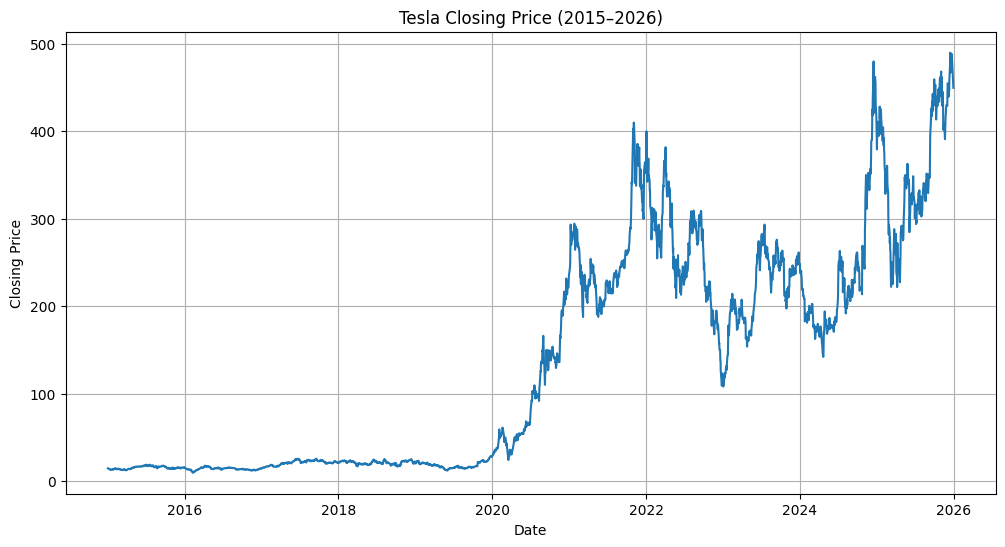

In [9]:
# Ensure proper datetime index
data.index = pd.to_datetime(data.index)

# Plot
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(data.index, data["Close"])

ax.set_title("Tesla Closing Price (2015–2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Closing Price")

# Fix x-axis formatting
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(True)
plt.show()

## Line Plot Interpretation

The Tesla closing price shows a strong upward trend over the period from 2015 to 2026 indicating long-term growth in the stock value. There are noticeable periods of high volatility particularly after 2020, where the price fluctuates significantly. This suggests that the time series is non-stationary as both the mean and variance change over time.

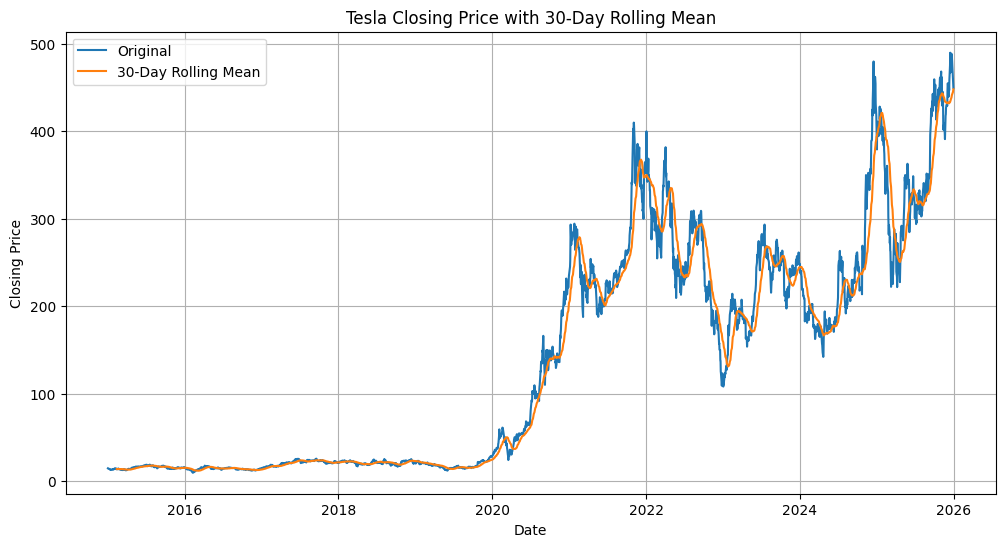

In [10]:
rolling_mean_30 = data["Close"].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(data.index, data["Close"], label="Original")
plt.plot(data.index, rolling_mean_30, label="30-Day Rolling Mean")

plt.title("Tesla Closing Price with 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

## Rolling Mean Analysis

The 30-day rolling mean smooths short-term fluctuations and clearly highlights the underlying upward trend in Tesla’s stock price. The rolling mean closely follows the overall direction of the series while reducing noise. Since the mean of the series changes over time this confirms that the data is non-stationary and will require transformation before modelling.

<Figure size 1000x600 with 0 Axes>

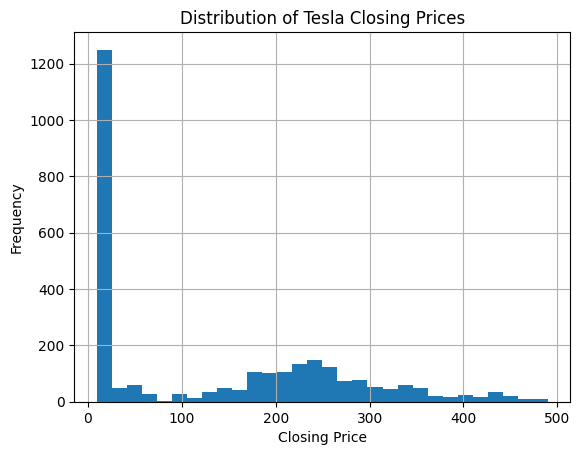

In [11]:
plt.figure(figsize=(10,6))
data["Close"].hist(bins=30)

plt.title("Distribution of Tesla Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.show()

## Distribution of Closing Prices

The histogram shows that the distribution of Tesla closing prices is positively skewed (right-skewed). A large number of observations are concentrated at lower price levels while fewer observations occur at higher price levels. This reflects the significant increase in Tesla’s stock price in recent years where early years had much lower prices compared to later periods.

In [12]:
result = adfuller(data["Close"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.7573168626235942
p-value: 0.8313396308969402
Critical Values:
1%: -3.4327414664215854
5%: -2.862596577381869
10%: -2.5673324502397423


## Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test was conducted to determine whether the Tesla closing price series is stationary.

The test results are as follows:
- ADF Statistic: -0.7573  
- p-value: 0.8313  

P-value is greater than 0.05 so fail to reject the null hypothesis. This shows that the time series is non-stationary. The ADF statistic is higher than all critical values so it also confirming non-stationarity.

Differencing is required to transform the data into a stationary series before applying time series models such as ARIMA.

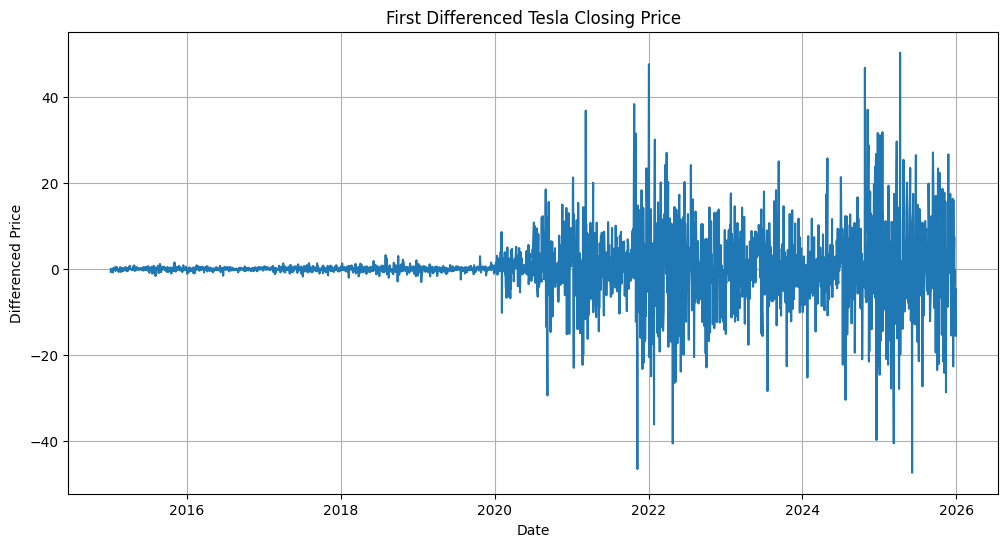

In [13]:
data_diff = data["Close"].diff().dropna()

plt.figure(figsize=(12,6))
plt.plot(data_diff)

plt.title("First Differenced Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.grid(True)
plt.show()

## Differencing

First-order differencing was applied to remove the trend from the time series. The differenced series fluctuates around zero so the trend has been successfully removed. This suggests that the data is closer to being stationary.

There are still periods of high volatility mostly after 2020 which indicates that the mean has been stabilised but the variance may still be changing over time.

In [14]:
result_diff = adfuller(data_diff)

print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])
print("Critical Values:")
for key, value in result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic (Differenced): -9.697042250865188
p-value (Differenced): 1.0972936009549594e-16
Critical Values:
1%: -3.4327423413176983
5%: -2.862596963765895
10%: -2.5673326559507625


## ADF Test After Differencing

The ADF test was applied to the differenced series to check for stationarity.

The results are:
- ADF Statistic: -9.6970  
- p-value: 1.097 × 10⁻¹⁶  

Since the p-value is significantly less than 0.05 reject the null hypothesis. This indicates that the differenced time series is stationary.

The ADF statistic is lower than all critical values which confirmins stationarity.

The series is now suitable for time series modelling using ARIMA.

<Figure size 1000x500 with 0 Axes>

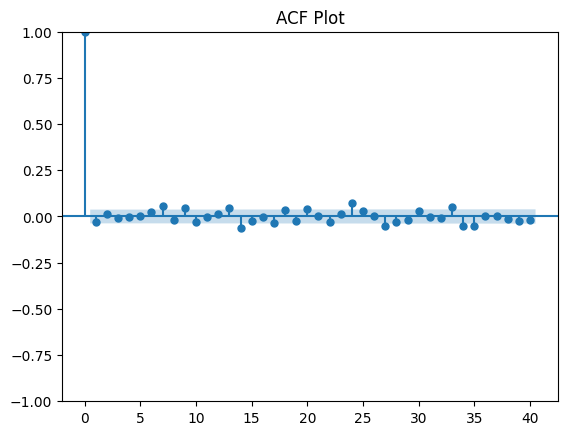

<Figure size 1000x500 with 0 Axes>

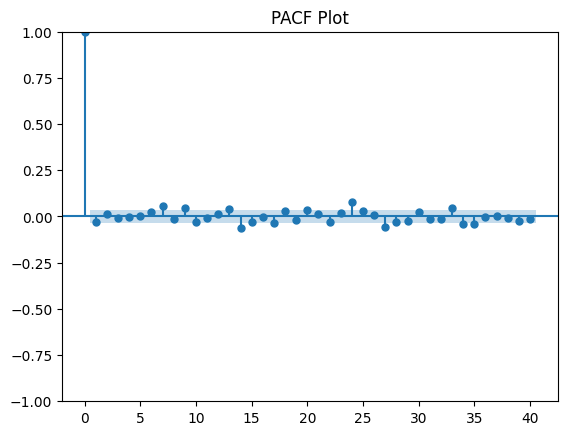

In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(data_diff, lags=40)
plt.title("ACF Plot")
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(data_diff, lags=40)
plt.title("PACF Plot")
plt.show()

## ACF and PACF Analysis

The ACF and PACF plots of the differenced series show no significant spikes beyond lag 0 with most values falling within the confidence intervals. This shows that there is little to no autocorrelation remaining in the series after differencing.

The differenced series behaves similarly to white noise and therefore a simple ARIMA(0,1,0) model may be appropriate. More complex models such as ARIMA(1,1,1) can also be tested for comparison.

In [17]:
from statsmodels.tsa.arima.model import ARIMA
data = data.asfreq('B')  # Business days
model = ARIMA(data["Close"], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                   TSLA   No. Observations:                 2869
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9359.903
Date:                Fri, 27 Mar 2026   AIC                          18725.806
Time:                        13:52:43   BIC                          18743.690
Sample:                    01-02-2015   HQIC                         18732.253
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5527      0.208     -2.655      0.008      -0.961      -0.145
ma.L1          0.5167      0.214      2.419      0.016       0.098       0.935
sigma2        49.7907      0.582     85.534      0.0

## ARIMA Model Results

An ARIMA(1,1,1) model was fitted to the Tesla stock price data. The results show that both the autoregressive (AR) and moving average (MA) components are statistically significant with p-values less than 0.05.

This indicates that past values and past errors both contribute meaningfully to the model. The ARIMA(1,1,1) model provides a reasonable fit to the data and is appropriate for forecasting.

The Ljung-Box test suggests that residuals are not significantly autocorrelated giving a good model fit.

c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  r

RMSE: 97.97381683981119


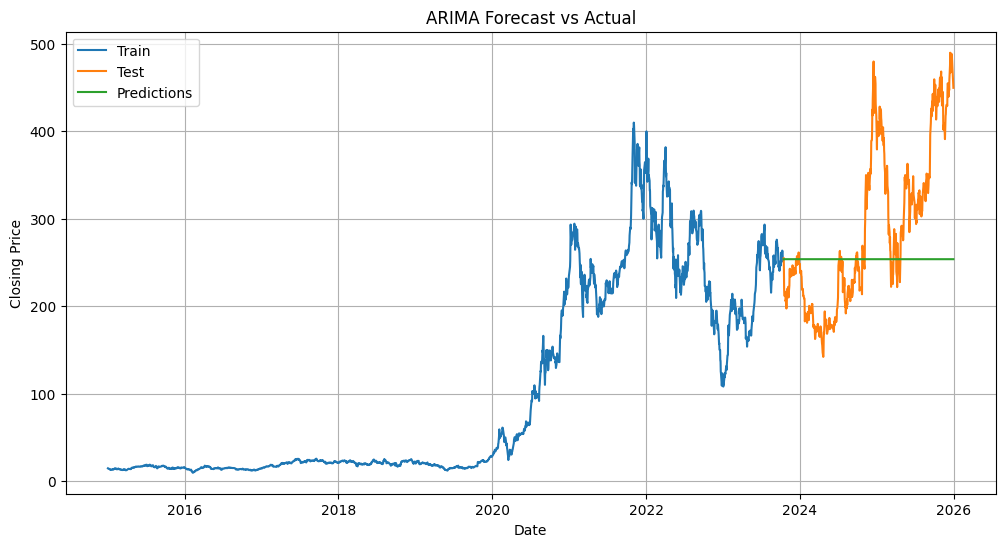

In [25]:
# clean close series
close_series = data["Close"].dropna().copy()
close_series.index = pd.DatetimeIndex(close_series.index)

# train/test split
train_size = int(len(close_series) * 0.8)
train = close_series.iloc[:train_size]
test = close_series.iloc[train_size:]

# fit model
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# forecast
predictions = model_fit.forecast(steps=len(test))

# convert both to plain numeric arrays
test_values = test.to_numpy()
pred_values = np.asarray(predictions)

# RMSE
rmse = np.sqrt(mean_squared_error(test_values, pred_values))
print("RMSE:", rmse)

# plot using test dates on x-axis
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test_values, label="Test")
plt.plot(test.index, pred_values, label="Predictions")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)
plt.show()

## Forecast Evaluation

The ARIMA(1,1,1) model was evaluated using Root Mean Squared Error (RMSE). The model had an RMSE value of **97.97** meaning that the model’s predictions differ from the actual Tesla closing prices by about 98 dollars on average.

High volatility of Tesla stock prices this suggests that the model captures the general movement of the series but forecasting accuracy is limited. This is expected in financial time series where prices are strongly influenced by unpredictable market events.

## Forecast Plot Analysis

The forecast plot compares the ARIMA(1,1,1) predictions with the actual Tesla closing prices in the test set. The model produces a relatively flat forecast line indicating that it predicts future values close to the most recent observed price.

This behaviour is common in financial time series where stock prices often follow a random walk process. The ARIMA model struggles to capture large fluctuations in the data leading to limited forecasting accuracy for highly volatile assets such as Tesla stock.